# Cellcharter

# Importing packages

In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import squidpy as sq
import anndata as ad
import cellcharter as cc
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

NotImplementedError: The legacy implementation is no longer supported

In [9]:
preprocessed_dir = Path("/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed")
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

[PosixPath('/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run141_ROI16'),
 PosixPath('/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run141_ROI7'),
 PosixPath('/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run141_ROI19'),
 PosixPath('/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run141_ROI17'),
 PosixPath('/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed/Run141_ROI23')]

In [67]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

/Users/jawadalaaedeen/Desktop/PhD/NMC/cellcharter/nmc_cellcharter_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [68]:
adata = adata[adata.obs["outcome_group"] == "long_term survival"]
adata.obs["exp_name"] = adata.obs["exp_name"].astype("category")

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4256/3681924160.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["exp_name"] = adata.obs["exp_name"].astype("category")
/Users/jawadalaaedeen/Desktop/PhD/NMC/cellcharter/nmc_cellcharter_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/jawadalaaedeen/Desktop/PhD/NMC/cellcharter/nmc_cellcharter_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [69]:
adata.obs

,cell_id,cell_type,level,parent_cell,type_no,Cell 3D Volume,Cell Bbox Bottom,Cell Bbox Left,Cell Bbox Right,Cell Bbox Top,...,ROI index,exp_name,patient_ID,age at diagnosis,sex,site,outcome,run,rois,outcome_group
0,1,Tumor_cells,1,0,14,2748,45,66,0,139,...,0,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival
1,2,NFC,1,0,21,1525,43,129,0,186,...,0,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival
2,3,M1_macrophages,2,10,11,5751,66,814,0,936,...,0,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival
3,4,MDSCs,1,0,20,2719,33,1005,0,1121,...,0,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival
4,5,Tumor_cells,1,0,14,2758,53,1121,0,1194,...,0,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33422,36281,NFC,1,0,21,1086,10068,2609,10038,2662,...,0,Run141_ROI17,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,17,long_term survival
33423,36282,Tumor_cells,1,0,14,1604,10068,8725,10021,8780,...,0,Run141_ROI17,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,17,long_term survival
33424,36283,Tumor_cells,1,0,14,936,10068,4326,10033,4382,...,0,Run141_ROI17,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,17,long_term survival
33425,36285,Tumor_cells,1,0,14,1700,10068,7929,10025,7989,...,0,Run141_ROI17,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,17,long_term survival


In [70]:
adata.raw = adata.copy()
for sample in adata.obs['exp_name'].cat.categories:
    adata.X[adata.obs['exp_name'] == sample, :] = sc.pp.scale(adata[adata.obs['exp_name'] == sample], copy=True).X

/Users/jawadalaaedeen/Desktop/PhD/NMC/cellcharter/nmc_cellcharter_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [75]:
condition_key = 'exp_name'
cell_type_key = 'cell_type'
conditions = adata.obs[condition_key].unique().tolist()

trvae_epochs = 500
surgery_epochs = 500

early_stopping_kwargs = {
    "early_stopping_metric": "val_unweighted_loss",
    "threshold": 0,
    "patience": 20,
    "reduce_lr": True,
    "lr_patience": 13,
    "lr_factor": 0.1,
}
trvae = cc.tl.TRVAE(
    adata=adata,
    condition_key=condition_key,
    conditions=conditions,
    recon_loss='mse',
    use_mmd=False,
)
trvae.train(
    n_epochs=trvae_epochs,
    alpha_epoch_anneal=200,
    early_stopping_kwargs=early_stopping_kwargs,
    enable_progress_bar=True,
    
)
trvae.save('trvae', overwrite=True)

ImportError: scarches is not installed. Please install scarches to use this method.

In [23]:
sq.gr.spatial_neighbors(adata, library_key='exp_name', coord_type='generic', delaunay=True)

In [24]:
adata.obs["exp_name"].cat.categories 

Index(['Run141_ROI17', 'Run141_ROI19'], dtype='object')

In [41]:
adata.uns['spatial'] = {'Run141_ROI17' : {}, "Run141_ROI19" : {}}
adata.uns

OrderedDict([('spatial_neighbors',
              {'connectivities_key': 'spatial_connectivities',
               'distances_key': 'spatial_distances',
               'params': {'n_neighbors': 6,
                'coord_type': 'generic',
                'radius': None,
                'transform': None}}),
             ('exp_name_colors', ['#1f77b4', '#ff7f0e']),
             ('spatial', {'Run141_ROI17': {}, 'Run141_ROI19': {}})])

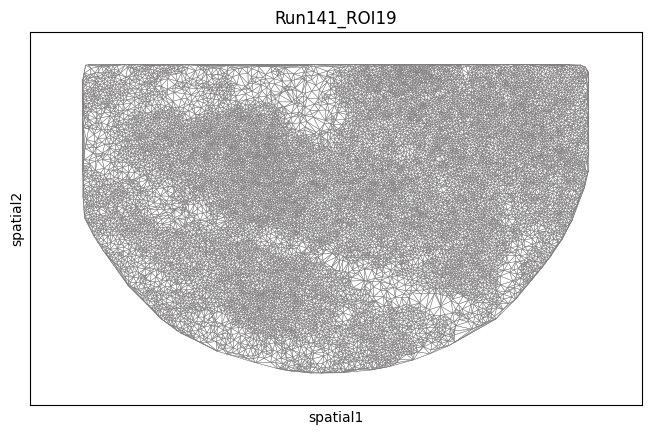

In [45]:
sq.pl.spatial_scatter(
    adata, 
    color='exp_name',
    library_key = "exp_name",
    img=None, 
    title=['Run141_ROI19'],
    connectivity_key='spatial_connectivities',
    edges_width=0.3,
    legend_loc=None,
    library_id=['Run141_ROI19']
    )

In [46]:
cc.gr.remove_long_links(adata)

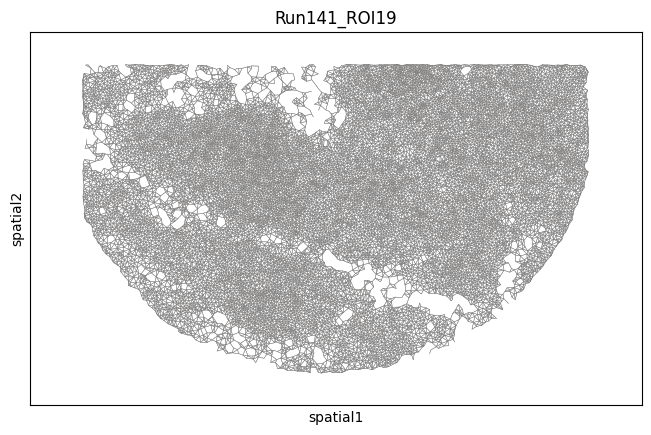

In [47]:
sq.pl.spatial_scatter(
    adata, 
    color='exp_name',
    library_key = "exp_name",
    img=None, 
    title=['Run141_ROI19'],
    connectivity_key='spatial_connectivities',
    edges_width=0.3,
    legend_loc=None,
    library_id=['Run141_ROI19']
    )

In [48]:
cc.gr.aggregate_neighbors(adata, n_layers=3)

100%|██████████| 4/4 [00:00<00:00, 38.71it/s]


In [50]:
model_params = {
    'random_state': 42,
    'trainer_params': {
        'accelerator':'mps',
        'enable_progress_bar': False
        },
    }

autok = cc.tl.ClusterAutoK(n_clusters=(4,20), model_class=cc.tl.GaussianMixture, 
                           model_params=model_params, 
                           max_runs=5)

In [52]:
autok.fit(adata, use_rep='X_cellcharter')

Iteration 1/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/jawadalaaedeen/Desktop/PhD/NMC/cellcharter/nmc_cellcharter_env/lib/python3.10/site-packages/torchgmm/bayes/core/normal.p

Iteration 2/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
H

Iteration 3/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available:

Iteration 4/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
H

Iteration 5/5


  0%|          | 0/19 [00:00<?, ?it/s]GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
H

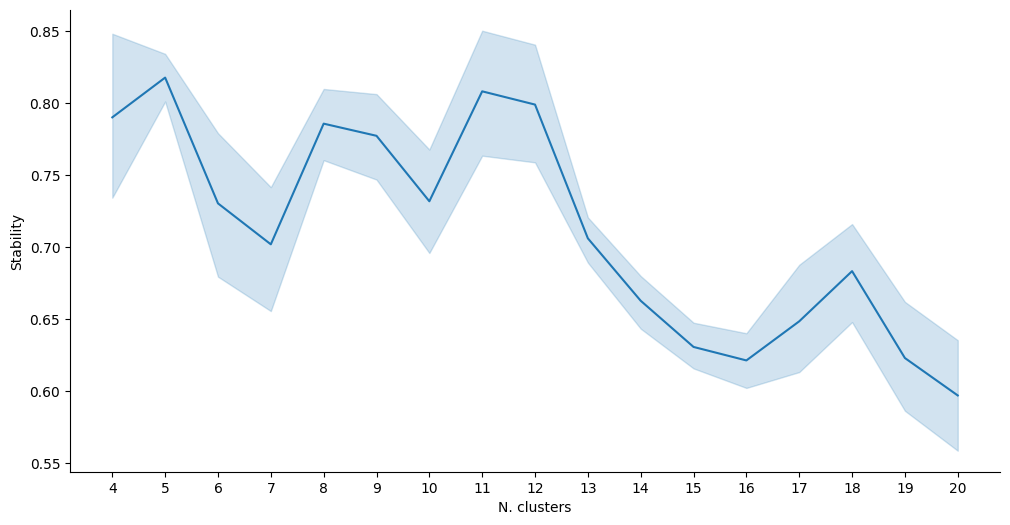

In [53]:
ax = cc.pl.autok_stability(autok, return_ax=True)
ax.figure.set_size_inches(12, 6)  

In [54]:
gmm = cc.tl.Cluster(
    n_clusters=5, 
    random_state=12345,
    trainer_params=dict(accelerator='mps', devices=1)
)

gmm.fit(adata, use_rep='X_cellcharter')
adata.obs['spatial_cluster'] = gmm.predict(adata, use_rep='X_cellcharter')

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=9` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 91: 100%|██████████| 1/1 [00:00<00:00, 19.80it/s, nll=-117.] 

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 41.73it/s] 


In [56]:
adata.obs

,cell_id,cell_type,level,parent_cell,type_no,Cell 3D Volume,Cell Bbox Bottom,Cell Bbox Left,Cell Bbox Right,Cell Bbox Top,...,exp_name,patient_ID,age at diagnosis,sex,site,outcome,run,rois,outcome_group,spatial_cluster
0,1,Tumor_cells,1,0,14,2748,45,66,0,139,...,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival,3
1,2,NFC,1,0,21,1525,43,129,0,186,...,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival,3
2,3,M1_macrophages,2,10,11,5751,66,814,0,936,...,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival,3
3,4,MDSCs,1,0,20,2719,33,1005,0,1121,...,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival,3
4,5,Tumor_cells,1,0,14,2758,53,1121,0,1194,...,Run141_ROI19,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,19,long_term survival,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33422,36281,NFC,1,0,21,1086,10068,2609,10038,2662,...,Run141_ROI17,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,17,long_term survival,0
33423,36282,Tumor_cells,1,0,14,1604,10068,8725,10021,8780,...,Run141_ROI17,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,17,long_term survival,2
33424,36283,Tumor_cells,1,0,14,936,10068,4326,10033,4382,...,Run141_ROI17,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,17,long_term survival,1
33425,36285,Tumor_cells,1,0,14,1700,10068,7929,10025,7989,...,Run141_ROI17,NMC_16,20,m,"cervical, A. carotis int. right",13,141.0,17,long_term survival,2


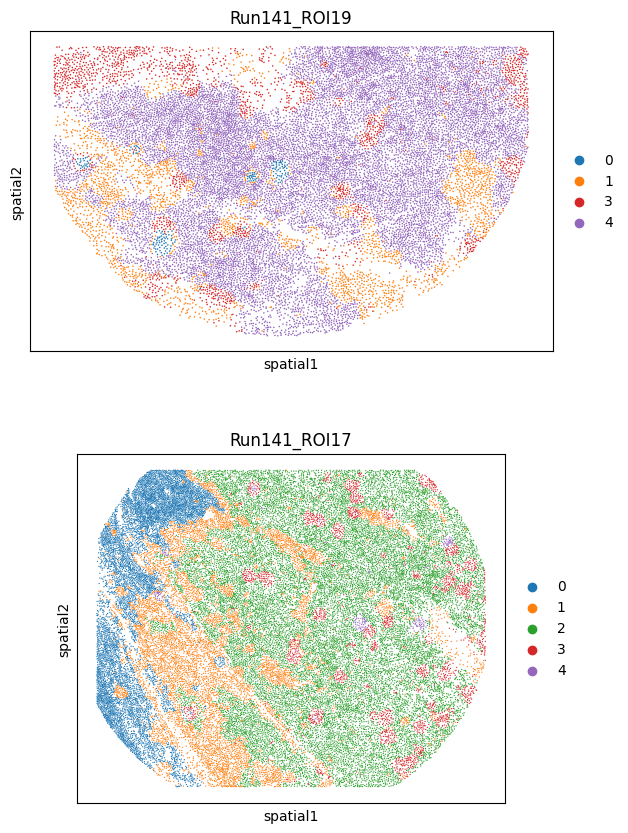

In [64]:
sq.pl.spatial_scatter(
    adata, 
    color='spatial_cluster',
    library_key = "exp_name",
    img=None,
    title = ['Run141_ROI19', "Run141_ROI17"], 
    size=20,
    ncols=1,
    library_id=['Run141_ROI19', 'Run141_ROI17'],
)

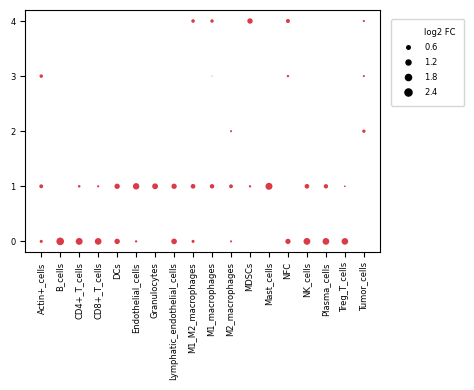

In [59]:
cc.gr.enrichment(adata, group_key='spatial_cluster', label_key='cell_type')
cc.pl.enrichment(adata, group_key='spatial_cluster', label_key='cell_type', figsize=(4,4), fontsize=6, dot_scale=1)